### Preprocessing EEG data coming from .edf format

<h4> Let's inspect how the data looks first </h4>

In [9]:
import mne
import scipy.io as sio
import numpy as np
import os
from mne.preprocessing import ICA
import mne_icalabel
import print_matlab_data as pmd
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")

# 1. Define Metadata (Crucial for .mat files)
sfreq = 200  # Sampling frequency for SEED dataset is usually 200Hz
# Channel names from your channel_62_pos.locs file
ch_names = [
    'Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8',
    'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1',
    'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6',
    'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz',
    'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'Oz', 'O2', 'CB2'
]
ch_types = ['eeg'] * len(ch_names)

# Create MNE Info object
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.read_custom_montage('channel_62_pos.locs')

# 2. Load a specific .mat file (Example for one file)
file_path = r"Preprocessed_EEG\1_20131027.mat"  # Change this to loop over your 45 files
mat_data = sio.loadmat(file_path)
display(mat_data.keys())  # Inspect keys to find EEG data

dict_keys(['__header__', '__version__', '__globals__', 'djc_eeg1', 'djc_eeg2', 'djc_eeg3', 'djc_eeg4', 'djc_eeg5', 'djc_eeg6', 'djc_eeg7', 'djc_eeg8', 'djc_eeg9', 'djc_eeg10', 'djc_eeg11', 'djc_eeg12', 'djc_eeg13', 'djc_eeg14', 'djc_eeg15'])

In [6]:
pmd.print_structure(mat_data)

root (dict):
  __header__: bytes
  __version__: str
  __globals__ (list, len=0):
  djc_eeg1 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg2 (np.ndarray, shape=(62, 46601), dtype=float64)
  djc_eeg3 (np.ndarray, shape=(62, 41201), dtype=float64)
  djc_eeg4 (np.ndarray, shape=(62, 47601), dtype=float64)
  djc_eeg5 (np.ndarray, shape=(62, 37001), dtype=float64)
  djc_eeg6 (np.ndarray, shape=(62, 39001), dtype=float64)
  djc_eeg7 (np.ndarray, shape=(62, 47401), dtype=float64)
  djc_eeg8 (np.ndarray, shape=(62, 43201), dtype=float64)
  djc_eeg9 (np.ndarray, shape=(62, 53001), dtype=float64)
  djc_eeg10 (np.ndarray, shape=(62, 47401), dtype=float64)
  djc_eeg11 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg12 (np.ndarray, shape=(62, 46601), dtype=float64)
  djc_eeg13 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg14 (np.ndarray, shape=(62, 47601), dtype=float64)
  djc_eeg15 (np.ndarray, shape=(62, 41201), dtype=float64)


In [7]:
pmd.print_full_tree(mat_data)

root (dict):
  __header__: bytes - b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri No
  __version__: str - '1.0'
  __globals__ (list, len=0):
  djc_eeg1 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg2 (np.ndarray, shape=(62, 46601), dtype=float64)
  djc_eeg3 (np.ndarray, shape=(62, 41201), dtype=float64)
  djc_eeg4 (np.ndarray, shape=(62, 47601), dtype=float64)
  djc_eeg5 (np.ndarray, shape=(62, 37001), dtype=float64)
  djc_eeg6 (np.ndarray, shape=(62, 39001), dtype=float64)
  djc_eeg7 (np.ndarray, shape=(62, 47401), dtype=float64)
  djc_eeg8 (np.ndarray, shape=(62, 43201), dtype=float64)
  djc_eeg9 (np.ndarray, shape=(62, 53001), dtype=float64)
  djc_eeg10 (np.ndarray, shape=(62, 47401), dtype=float64)
  djc_eeg11 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg12 (np.ndarray, shape=(62, 46601), dtype=float64)
  djc_eeg13 (np.ndarray, shape=(62, 47001), dtype=float64)
  djc_eeg14 (np.ndarray, shape=(62, 47601), dtype=float64)
  djc_eeg15 (np.ndarray, shape=

In [10]:
# 3. Iterate over trials inside the .mat file
# SEED .mat files usually have keys like 'djc_eeg1', 'djc_eeg2'... or just keys that are not metadata
for key in mat_data.keys():
    if key.startswith('__'): # Skip metadata keys like __header__
        continue
    
    print(f"Processing trial: {key}")
    data = mat_data[key] # Shape should be (62, n_samples)
    
    # Transpose if necessary: MNE expects (n_channels, n_samples)
    # SEED data is often (62, n_samples), but check shape.
    if data.shape[0] != 62:
        data = data.T
        
    # Create Raw object
    raw = mne.io.RawArray(data, info)
    raw.set_montage(montage, on_missing='ignore')

    
    
    # --- FROM HERE, APPLY YOUR EXISTING PIPELINE ---
    
    # Filter (Optional if already filtered, but good for ICA stability)
    raw_ica = raw.copy().filter(1.0, None)
    
    # Run ICA
    ica = ICA(n_components=15, max_iter='auto', random_state=97)
    ica.fit(raw_ica)
    
    # Label components
    ic_labels = mne_icalabel.label_components(raw, ica, method="iclabel")
    
    # Exclude artifacts
    labels = ic_labels["labels"]
    exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
    print(f"Excluding components: {exclude_idx}")
    
    # Apply cleaning
    ica.apply(raw, exclude=exclude_idx)
    
    # Save or Store the cleaned data
    # raw.get_data() returns the cleaned numpy array
    cleaned_data = raw.get_data()
    
    # You can save this back to a new .mat file or process further
    break # Remove this break to process all trials

Processing trial: djc_eeg1
Creating RawArray with float64 data, n_channels=62, n_times=47001
    Range : 0 ... 47000 =      0.000 ...   235.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Fitting ICA to data using 62 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.6s.
Excluding components: [0, 1, 2, 4, 11]
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 5 ICA components
    Projecting back using 62 PCA components


<h3>Now that we know this works, I can run an automated script and get some data and result out here</h3>

In [ ]:
import mne
import scipy.io as sio
import numpy as np
import os
from mne.preprocessing import ICA
import mne_icalabel

# --- Configuration ---
input_folder = "Preprocessed_EEG"
output_folder = "Cleaned_EEG_ICA"
os.makedirs(output_folder, exist_ok=True)

# Define Metadata
sfreq = 200
ch_names = [
    'Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8',
    'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1',
    'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6',
    'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz',
    'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'Oz', 'O2', 'CB2'
]
ch_types = ['eeg'] * len(ch_names)
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.read_custom_montage('channel_62_pos.locs')

# --- Processing Loop ---
# Get all .mat files
files = [f for f in os.listdir(input_folder) if f.endswith('.mat')]

for file_name in files:
    print(f"Processing file: {file_name}")
    file_path = os.path.join(input_folder, file_name)
    
    try:
        mat_data = sio.loadmat(file_path)
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        continue
        
    cleaned_data_dict = {}
    
    # Copy non-EEG keys (like labels) to the new dictionary
    for key in mat_data:
        if not key.startswith('__') and not key.startswith('eeg_') and not key.startswith('djc_eeg'):
             cleaned_data_dict[key] = mat_data[key]

    # Iterate over trials (eeg_1 ... eeg_15)
    # Note: Keys might be 'eeg_1' or 'djc_eeg1' depending on the file version. 
    # We iterate all keys and check if they look like EEG data.
    for key in mat_data.keys():
        if key.startswith('__'): continue
        
        # Check if this key contains EEG data (usually shape (62, N) or (N, 62))
        data = mat_data[key]
        if not isinstance(data, np.ndarray) or data.ndim != 2:
            continue
            
        # Heuristic: EEG data usually has 62 channels
        if data.shape[0] == 62:
            pass # Correct orientation
        elif data.shape[1] == 62:
            data = data.T # Transpose
        else:
            continue # Not an EEG data array
            
        print(f"  Cleaning trial: {key}")
        
        # Create Raw object
        raw = mne.io.RawArray(data, info)
        raw.set_montage(montage)
        
        # Filter for ICA (1Hz highpass)
        # Note: We filter a COPY for ICA calculation, but apply cleaning to the ORIGINAL (or 0.1Hz filtered) data
        # to preserve low frequencies if needed. 
        raw_ica = raw.copy().filter(1.0, 40.0, verbose=False)
        
        # Run ICA
        ica = ICA(n_components=15, max_iter='auto', random_state=97, verbose=False)
        ica.fit(raw_ica)
        
        # Label and Exclude
        ic_labels = mne_icalabel.label_components(raw_ica, ica, method="iclabel")
        labels = ic_labels["labels"]
        exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
        
        # Apply to original data
        ica.apply(raw, exclude=exclude_idx, verbose=False)
        
        # Store cleaned data back to dictionary
        cleaned_data_dict[key] = raw.get_data()
        
    # Save the new .mat file
    save_path = os.path.join(output_folder, file_name)
    sio.savemat(save_path, cleaned_data_dict)
    print(f"Saved cleaned file: {save_path}")

print("All files processed.")

In [25]:
#loading edf file
file_path="GA41705E.edf"
#file_path="EDF zapisi/HS1EC.edf"
file = os.path.basename(file_path)

raw = mne.io.read_raw_edf(file_path, preload=True)
print(f"Successfully loaded: {file}")

Extracting EDF parameters from D:\GA41705E.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 360999  =      0.000 ...  1804.995 secs...
Successfully loaded: GA41705E.edf


In [26]:
channels_to_keep = [ch for ch in raw.ch_names if 'EEG' in ch]
raw.pick_channels(channels_to_keep)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | GA41705E.edf, 21 x 361000 (1805.0 s), ~57.9 MiB, data loaded>

In [27]:
def remove_eeg_and_suffix(raw):
    channel_names = raw.ch_names  # Get channel names from raw object
    
    # Remove "EEG " prefix and everything after the dash (including the dash itself)
    cleaned_channel_names = [
        name.replace('EEG ', '').split('-')[0] for name in channel_names
    ]
    
    # Create a mapping from old channel names to new channel names
    rename_map = {old: new for old, new in zip(channel_names, cleaned_channel_names)}
    
    # Rename channels in the raw object
    raw.rename_channels(rename_map)
    
    return raw

In [28]:
map = {ch: ch.replace('EEG ', '') for ch in raw.ch_names if 'EEG' in ch}
raw = remove_eeg_and_suffix(raw)
raw


<RawEDF | GA41705E.edf, 21 x 361000 (1805.0 s), ~57.9 MiB, data loaded>

In [29]:
def keep_selected_channels(raw):
    # Define allowed starting letters
    allowed_prefixes = ('F', 'C', 'P', 'T', 'O')
    
    # Filter channels that start with the allowed letters
    channels_to_keep = [ch for ch in raw.ch_names if ch.startswith(allowed_prefixes)]
    
    # Pick only the allowed channels
    raw.pick_channels(channels_to_keep)
    
    return raw

In [30]:
raw = keep_selected_channels(raw)
raw

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | GA41705E.edf, 19 x 361000 (1805.0 s), ~52.3 MiB, data loaded>

In [31]:
montage = mne.channels.make_standard_montage(kind='standard_1020')
raw.set_montage(montage, on_missing='ignore')
picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False, stim=False)

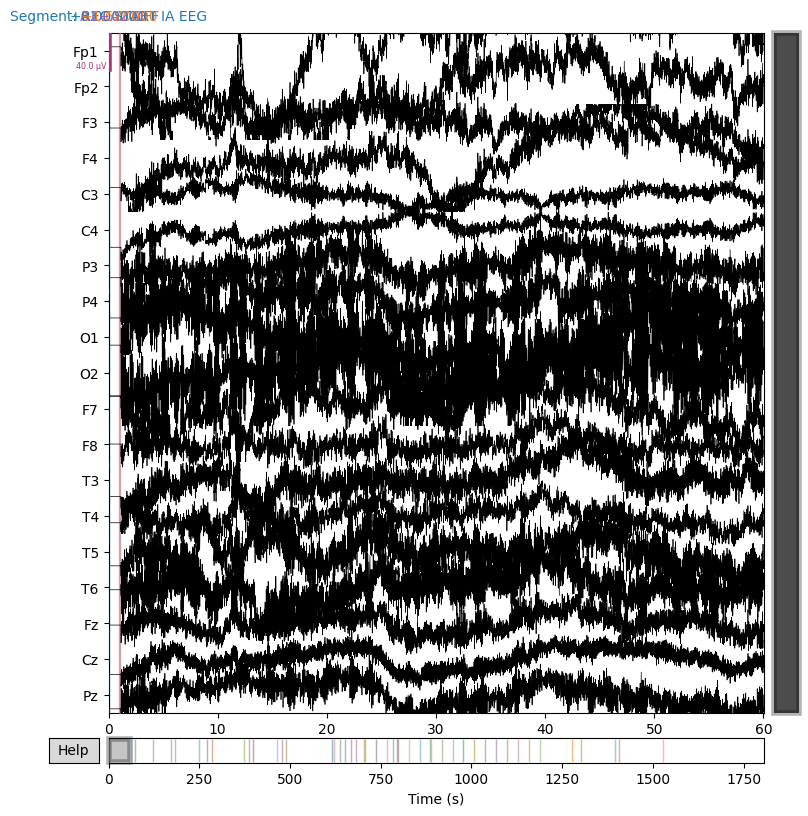

In [32]:
raw.plot(duration=60, proj=False, n_channels=len(raw.ch_names))
plt.ioff()  # Turn off interactive mode

In [33]:
#filtering and rereferencing the data
raw.filter(0.1, 40, picks=picks, phase='zero-double', h_trans_bandwidth=1)
raw.set_eeg_reference(ref_channels='average', ch_type='eeg')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-12 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 1.00 Hz (-12 dB cutoff frequency: 40.50 Hz)
- Filter length: 6601 samples (33.005 s)

Applying average reference.
Applying a custom ('EEG',) reference.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


<RawEDF | GA41705E.edf, 19 x 361000 (1805.0 s), ~52.4 MiB, data loaded>

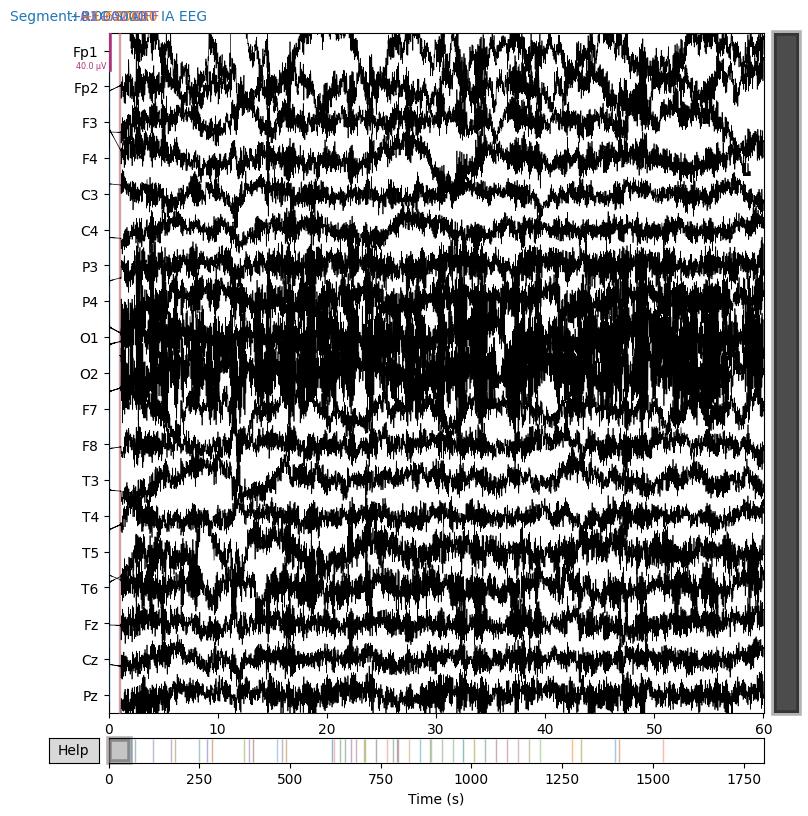

In [34]:
raw.plot(duration=60, proj=False, n_channels=len(raw.ch_names))
plt.ioff()  # Turn off interactive mode

In [35]:
from mne.preprocessing import ICA
ica = ICA(
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica.fit(raw)
ica

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 18 components
Computing Extended Infomax ICA
Fitting ICA took 24.1s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (361000 samples)
ICA components,18
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


In [36]:
ic_labels = mne_icalabel.label_components(raw, ica, method="iclabel")

C:\Users\Nikolina\AppData\Local\Temp\ipykernel_11160\1342001872.py:1: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = mne_icalabel.label_components(raw, ica, method="iclabel")


Creating RawArray with float64 data, n_channels=18, n_times=361000
    Range : 0 ... 360999 =      0.000 ...  1804.995 secs
Ready.


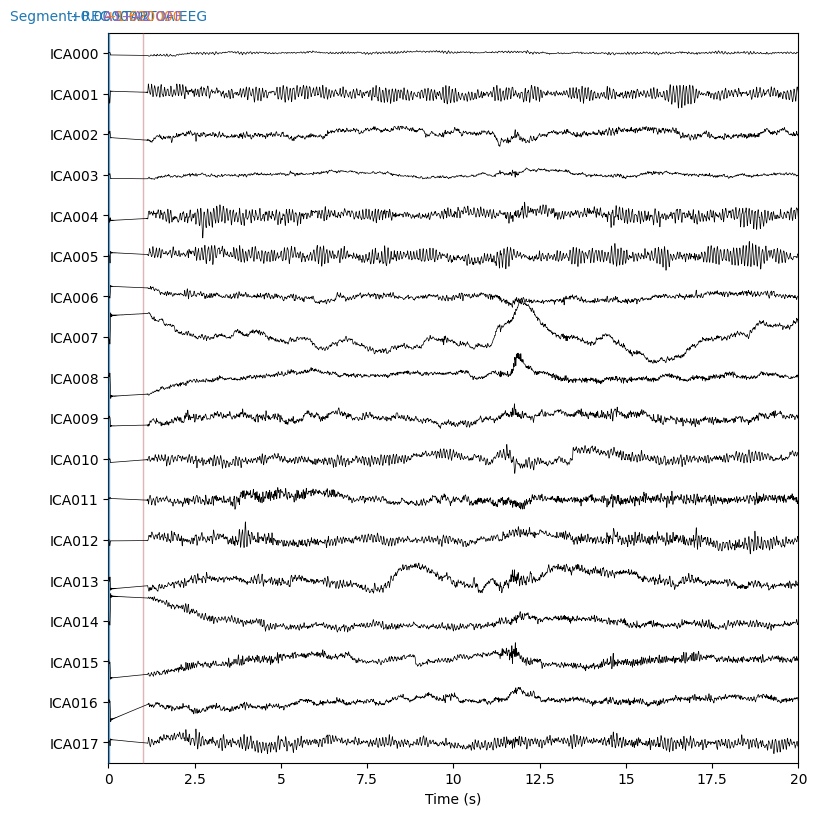

In [37]:
ica.plot_sources(raw, show_scrollbars=False, show=True)
plt.ioff()  # Turn off interactive mode

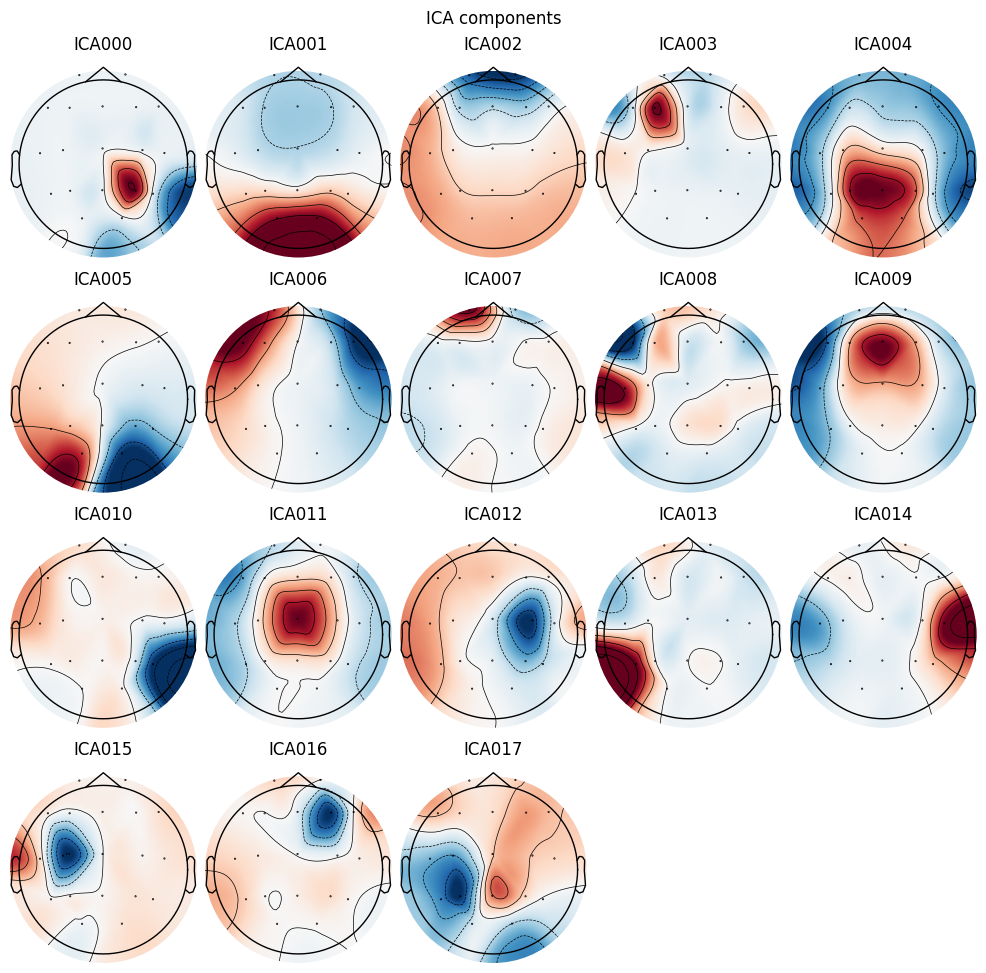

In [38]:
ica.plot_components()
plt.ioff()  # Turn off interactive mode

In [39]:
print(ic_labels["labels"])
labels = ic_labels["labels"]
exclude_idx = [
    idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
]
print(f"Excluding these ICA components: {exclude_idx}")

['brain', 'brain', 'eye blink', 'other', 'brain', 'brain', 'eye blink', 'eye blink', 'other', 'brain', 'brain', 'brain', 'brain', 'brain', 'other', 'brain', 'other', 'brain']
Excluding these ICA components: [2, 6, 7]


In [40]:
ica.apply(raw, exclude=exclude_idx)

Applying ICA to Raw instance
    Transforming to ICA space (18 components)
    Zeroing out 3 ICA components
    Projecting back using 19 PCA components


<RawEDF | GA41705E.edf, 19 x 361000 (1805.0 s), ~52.4 MiB, data loaded>

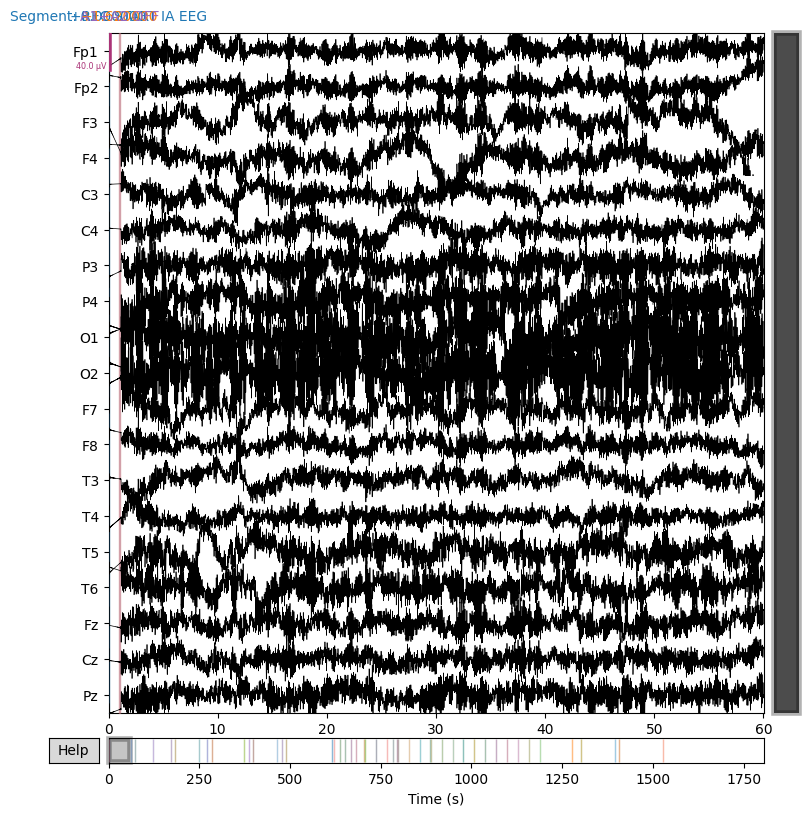

In [41]:
raw.plot(duration=60, proj=False, n_channels=len(raw.ch_names))
plt.ioff()  # Turn off interactive mode

### Save preprocessed file

In [42]:
name_part, extension = file.rsplit(".", 1)  # Split filename and extension
extension='set'
preprocessed_file_name = f"{name_part}_preprocessed.{extension}"
preprocessed_file_name

'GA41705E_preprocessed.set'

In [43]:
mne.export.export_raw(preprocessed_file_name, raw, fmt='eeglab')